In [1]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
from sklearn.utils import class_weight
import time
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50

2026-03-02 21:21:27.332879: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available!")
    print("GPU devices:", gpus)
else:
    print("GPU is NOT available. Using CPU.")


GPU is available!
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Before augmentation

Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Class Weights: {0: 0.8388645552560647, 1: 0.6129369768586903, 2: 2.259301270417423, 3: 1.3627531472359058}
312/312 [==============================] - 210s 638ms/step - loss: 1.1802 - accuracy: 0.4880 - val_loss: 0.9682 - val_accuracy: 0.5935


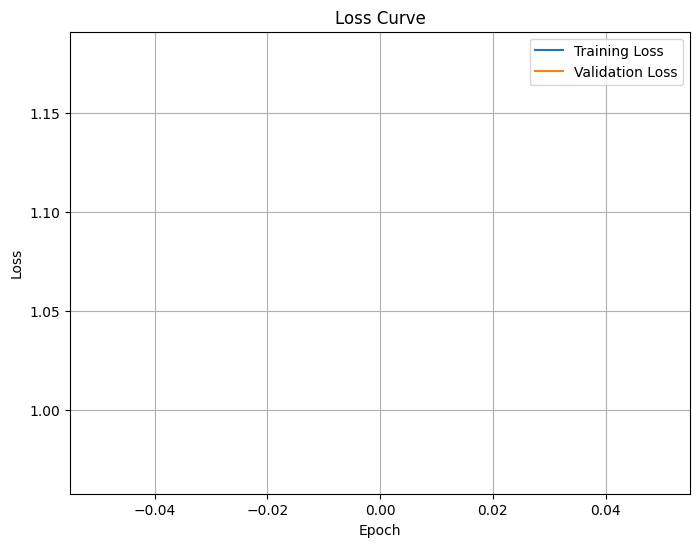

78/78 [==============================] - 8s 97ms/step


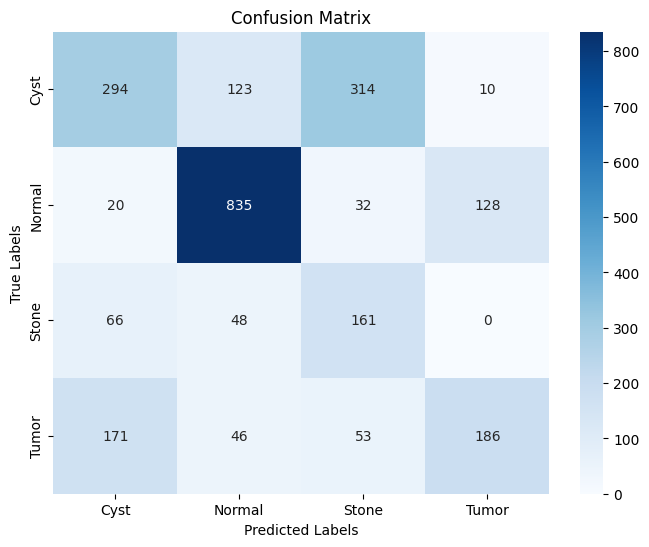

Training Time: 210.88 seconds
Testing Time: 8.47 seconds
Confusion Matrix:
 [[294 123 314  10]
 [ 20 835  32 128]
 [ 66  48 161   0]
 [171  46  53 186]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.53      0.40      0.46       741
      Normal       0.79      0.82      0.81      1015
       Stone       0.29      0.59      0.39       275
       Tumor       0.57      0.41      0.48       456

    accuracy                           0.59      2487
   macro avg       0.55      0.55      0.53      2487
weighted avg       0.62      0.59      0.60      2487

Overall Accuracy: 0.5935
Accuracy for class 'Cyst': 0.3968
Accuracy for class 'Normal': 0.8227
Accuracy for class 'Stone': 0.5855
Accuracy for class 'Tumor': 0.4079


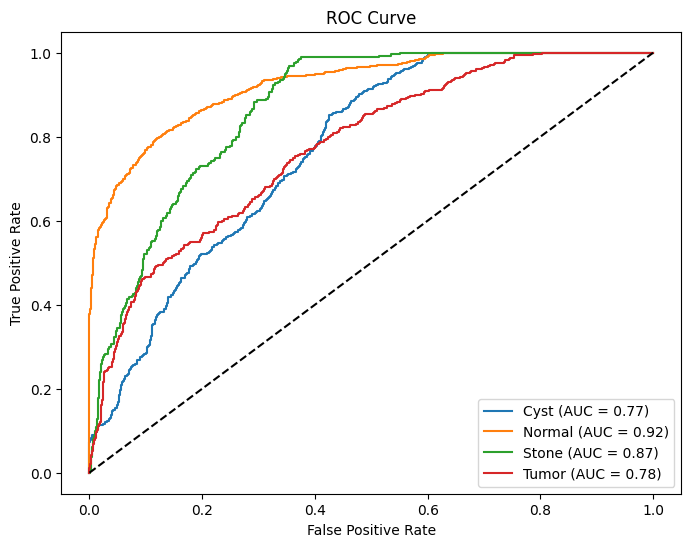

Overall Accuracy: 59.35%
Precision: 54.72%
Recall: 55.32%
F1-Score: 53.14%


In [ ]:


IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 1
DATASET_PATH =  "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

datagen = ImageDataGenerator(
    rescale=1./255,               
    rotation_range=20,             
    width_shift_range=0.2,        
    height_shift_range=0.2,        
    shear_range=0.15,             
    zoom_range=0.15,              
    horizontal_flip=True,          
    fill_mode='nearest',           
    validation_split=0.2           
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
y_train = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights
)
training_time = time.time() - start_train_time

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()



start_test_time = time.time()

y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

accuracy = np.sum(y_pred_classes == y_true) / len(y_true)

precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

# Print results
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

### After augmentation and class weight

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 20
DATASET_PATH =  "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

datagen = ImageDataGenerator(
    rescale=1./255,               
    rotation_range=20,             
    width_shift_range=0.2,        
    height_shift_range=0.2,        
    shear_range=0.15,             
    zoom_range=0.15,              
    horizontal_flip=True,          
    fill_mode='nearest',           
    validation_split=0.2           
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
y_train = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
]
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)
training_time = time.time() - start_train_time

Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Class Weights: {0: np.float64(0.8388645552560647), 1: np.float64(0.6129369768586903), 2: np.float64(2.259301270417423), 3: np.float64(1.3627531472359058)}


I0000 00:00:1772464927.282504    1315 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:10:00.0, compute capability: 8.6


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Epoch 1/20


2026-03-02 21:22:31.176779: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f9004015320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-02 21:22:31.176811: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-03-02 21:22:31.419043: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-02 21:22:33.013438: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-02 21:22:33.790724: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_6977', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1772464963.605868    1894 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at 

 72/312 ━━━━━━━━━━━━━━━━━━━━ 1:14 310ms/step - accuracy: 0.2672 - loss: 1.4715

...

312/312 ━━━━━━━━━━━━━━━━━━━━ 116s 370ms/step - accuracy: 0.6403 - loss: 0.8883 - val_accuracy: 0.6417 - val_loss: 1.0563
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 107s 341ms/step - accuracy: 0.7042 - loss: 0.7413 - val_accuracy: 0.6176 - val_loss: 1.0678
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 107s 342ms/step - accuracy: 0.7396 - loss: 0.6660 - val_accuracy: 0.6441 - val_loss: 1.2848
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.7684 - loss: 0.5892

312/312 ━━━━━━━━━━━━━━━━━━━━ 105s 336ms/step - accuracy: 0.7694 - loss: 0.5824 - val_accuracy: 0.6277 - val_loss: 1.0490
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 104s 334ms/step - accuracy: 0.7820 - loss: 0.5418 - val_accuracy: 0.6361 - val_loss: 1.1521
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 104s 333ms/step - accuracy: 0.7972 - loss: 0.5060 - val_accuracy: 0.6309 - val_loss: 1.1869
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8125 - loss: 0.4930

312/312 ━━━━━━━━━━━━━━━━━━━━ 107s 343ms/step - accuracy: 0.8102 - loss: 0.4881 - val_accuracy: 0.6840 - val_loss: 0.9610
Epoch 9/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 104s 334ms/step - accuracy: 0.8285 - loss: 0.4478 - val_accuracy: 0.6570 - val_loss: 1.1972
Epoch 10/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 105s 337ms/step - accuracy: 0.8356 - loss: 0.4252 - val_accuracy: 0.6944 - val_loss: 1.1642
Epoch 11/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 107s 344ms/step - accuracy: 0.8467 - loss: 0.3950 - val_accuracy: 0.6852 - val_loss: 1.1488
Epoch 12/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.8508 - loss: 0.3987

312/312 ━━━━━━━━━━━━━━━━━━━━ 106s 340ms/step - accuracy: 0.8544 - loss: 0.3868 - val_accuracy: 0.7346 - val_loss: 0.9413
Epoch 13/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 107s 343ms/step - accuracy: 0.8602 - loss: 0.3687 - val_accuracy: 0.6864 - val_loss: 1.1675
Epoch 14/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 110s 353ms/step - accuracy: 0.8606 - loss: 0.3608 - val_accuracy: 0.6663 - val_loss: 1.1831
Epoch 15/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 106s 339ms/step - accuracy: 0.8695 - loss: 0.3354 - val_accuracy: 0.6574 - val_loss: 1.2027
Epoch 16/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 105s 336ms/step - accuracy: 0.8779 - loss: 0.3186 - val_accuracy: 0.6341 - val_loss: 1.1630
Epoch 17/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8807 - loss: 0.3161

312/312 ━━━━━━━━━━━━━━━━━━━━ 106s 339ms/step - accuracy: 0.8806 - loss: 0.3080 - val_accuracy: 0.7318 - val_loss: 0.9120
Epoch 18/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 108s 345ms/step - accuracy: 0.8866 - loss: 0.3010 - val_accuracy: 0.6566 - val_loss: 1.3191
Epoch 19/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 106s 339ms/step - accuracy: 0.8933 - loss: 0.2825 - val_accuracy: 0.6224 - val_loss: 1.3241
Epoch 20/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 105s 337ms/step - accuracy: 0.8948 - loss: 0.2756 - val_accuracy: 0.6253 - val_loss: 1.6193


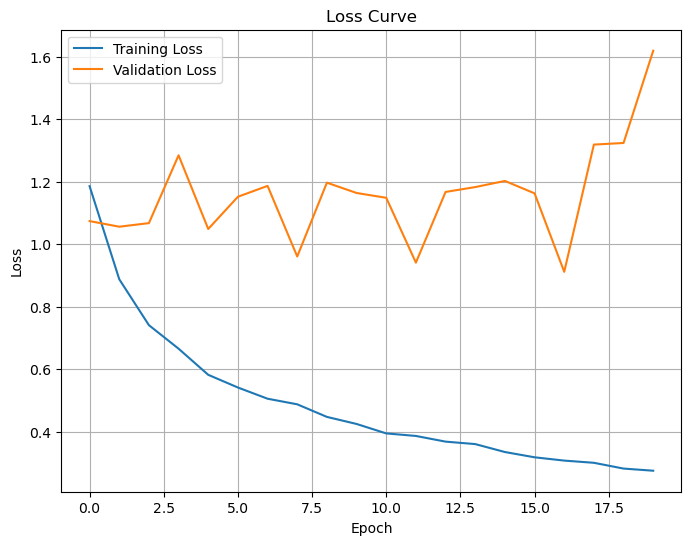

78/78 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step


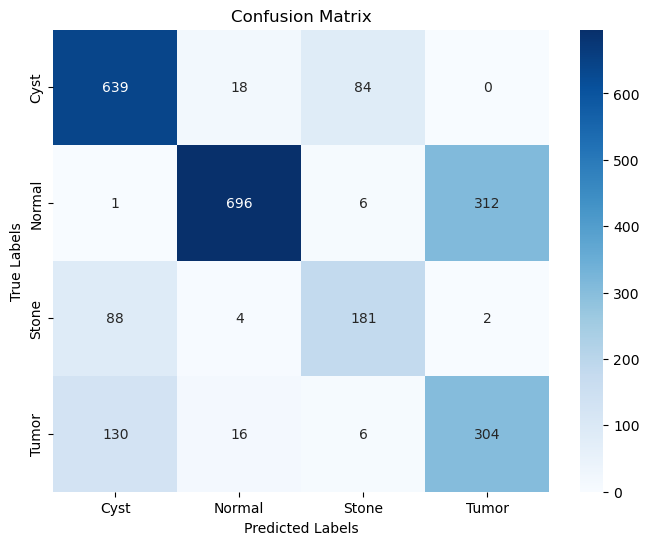

Training Time: 2184.38 seconds
Testing Time: 19.63 seconds
Confusion Matrix:
 [[639  18  84   0]
 [  1 696   6 312]
 [ 88   4 181   2]
 [130  16   6 304]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.74      0.86      0.80       741
      Normal       0.95      0.69      0.80      1015
       Stone       0.65      0.66      0.66       275
       Tumor       0.49      0.67      0.57       456

    accuracy                           0.73      2487
   macro avg       0.71      0.72      0.70      2487
weighted avg       0.77      0.73      0.74      2487

Overall Accuracy: 0.7318
Accuracy for class 'Cyst': 0.8623
Accuracy for class 'Normal': 0.6857
Accuracy for class 'Stone': 0.6582
Accuracy for class 'Tumor': 0.6667


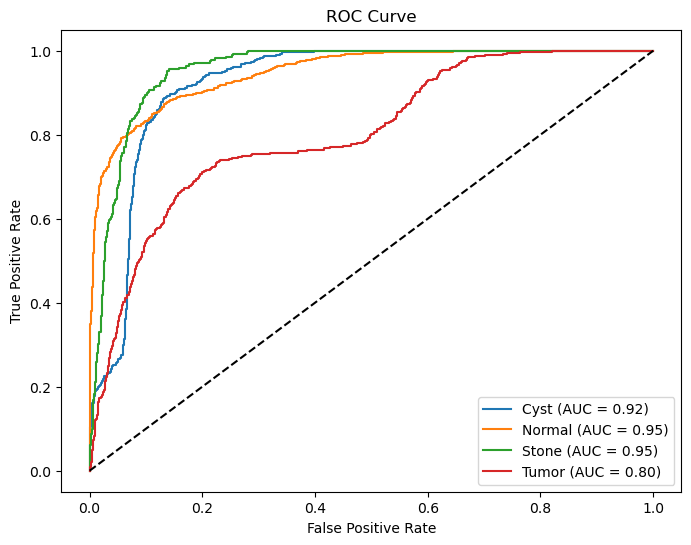

Overall Accuracy: 73.18%
Precision: 70.96%
Recall: 71.82%
F1-Score: 70.43%


In [7]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


start_test_time = time.time()

y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

accuracy = np.sum(y_pred_classes == y_true) / len(y_true)

precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

# Print results
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")